In [7]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

Matplotlib is building the font cache; this may take a moment.


In [8]:
df=pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\AMDARI\Finlora Finance\notebook\cleaned_data2.csv")

In [9]:
df.head(2)

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd,transaction_id,timestamp,...,is_fraud,Standardized_Description,Fallback_Merchant,year,month,day,exchange_rate,amount_in_GBP,amount_in_USD,is_same_day
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,FLR250216186265,2025-02-16 14:55:35,...,0,CNP PURCHASE - BOLT,Bolt,2022,August,28,0.00056,47.170480,61.321624,0
1,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,FLR250423143305,2025-04-23 13:35:40,...,0,WEB PURCHASE - SLACK,Slack,2022,August,28,0.00056,5.120265,6.656344,0


In [10]:
df.head(1)

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd,transaction_id,timestamp,...,is_fraud,Standardized_Description,Fallback_Merchant,year,month,day,exchange_rate,amount_in_GBP,amount_in_USD,is_same_day
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,FLR250216186265,2025-02-16 14:55:35,...,0,CNP PURCHASE - BOLT,Bolt,2022,August,28,0.00056,47.17048,61.321624,0


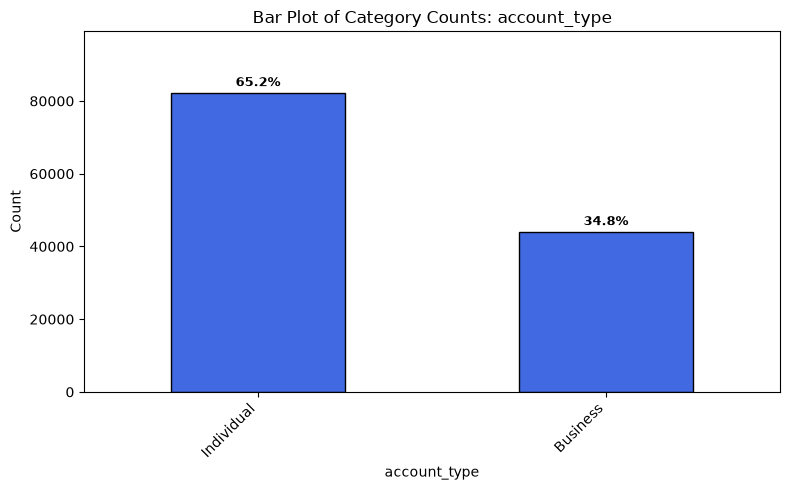

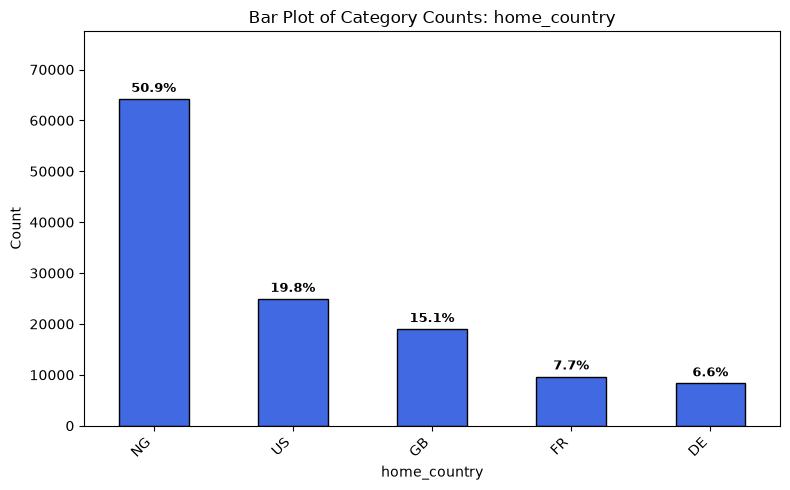

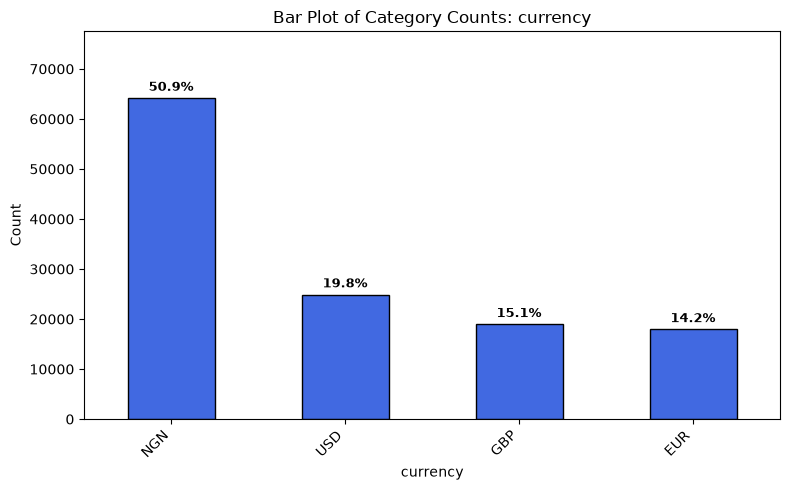

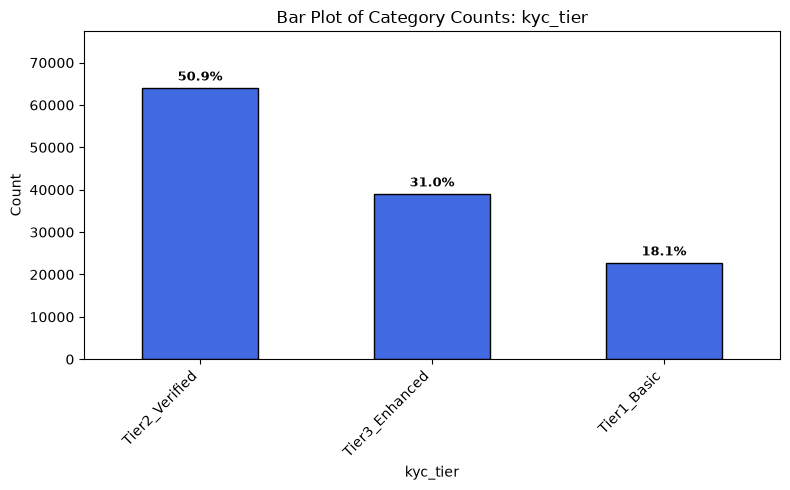

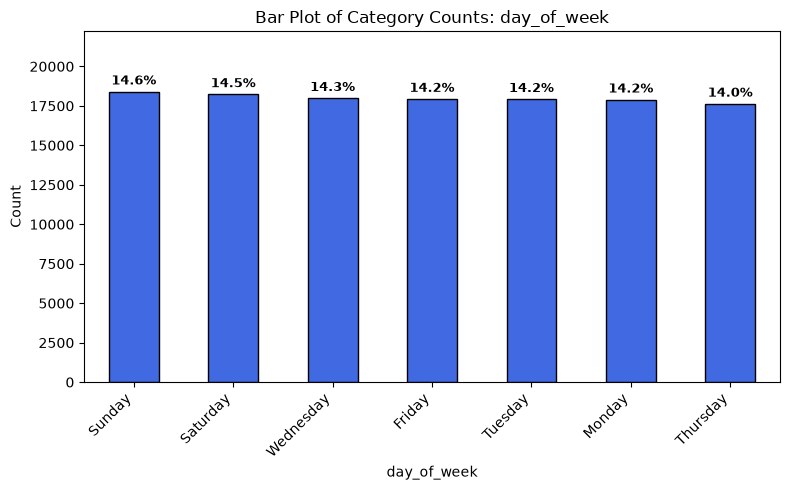

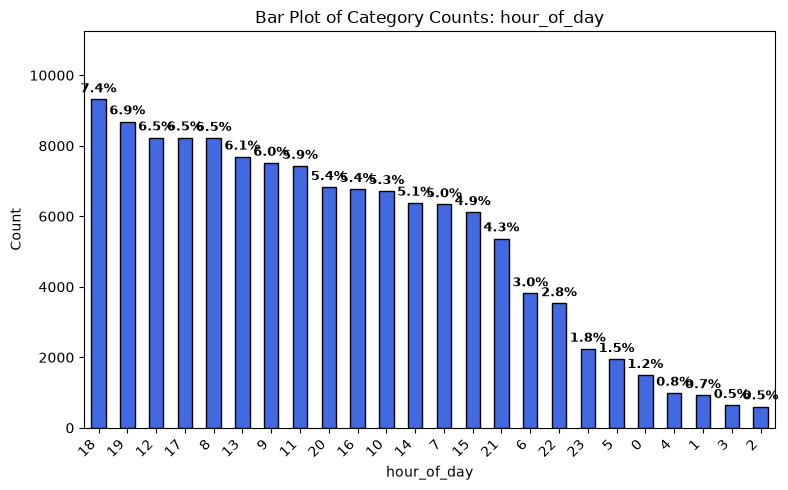

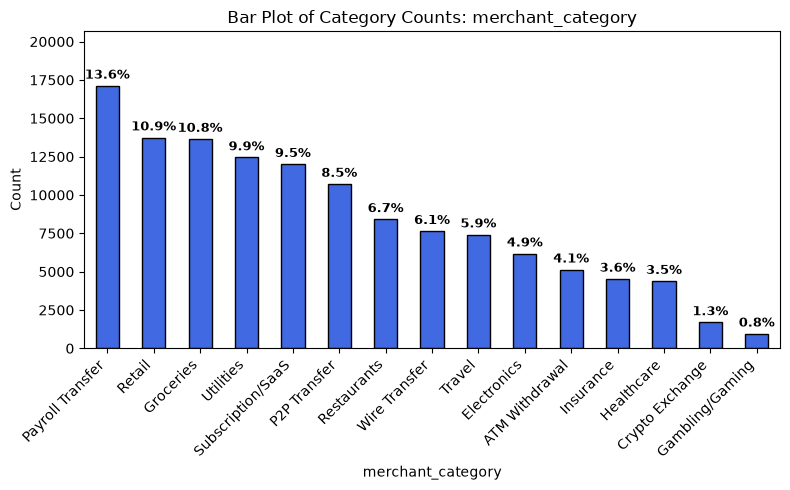

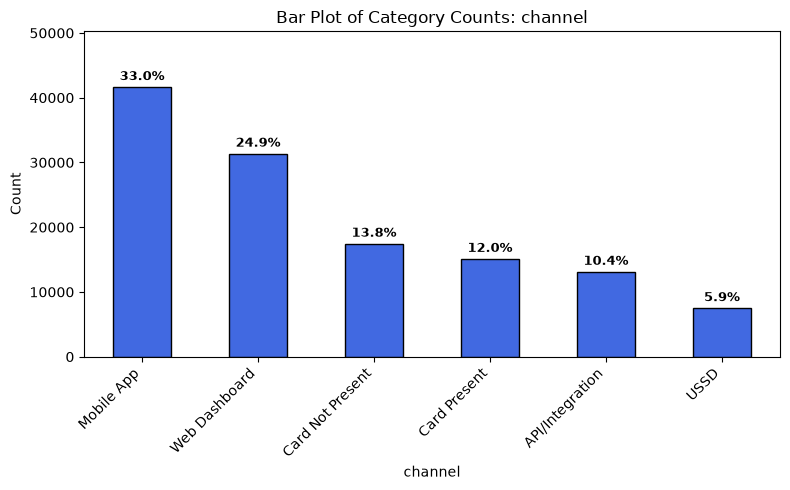

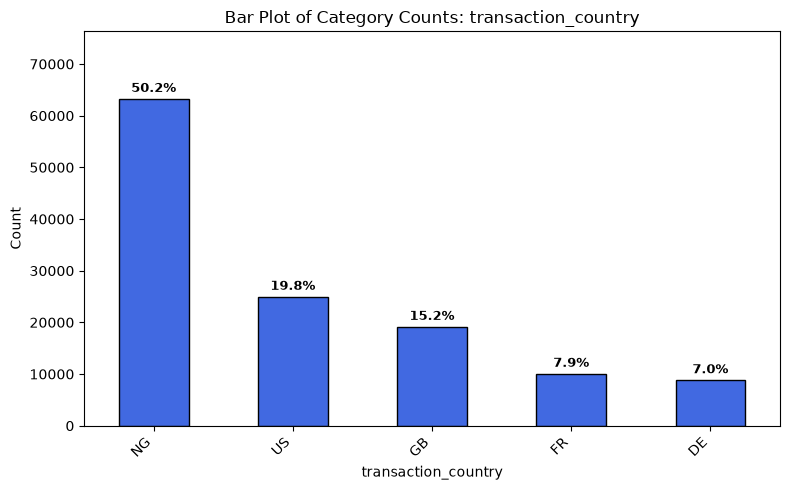

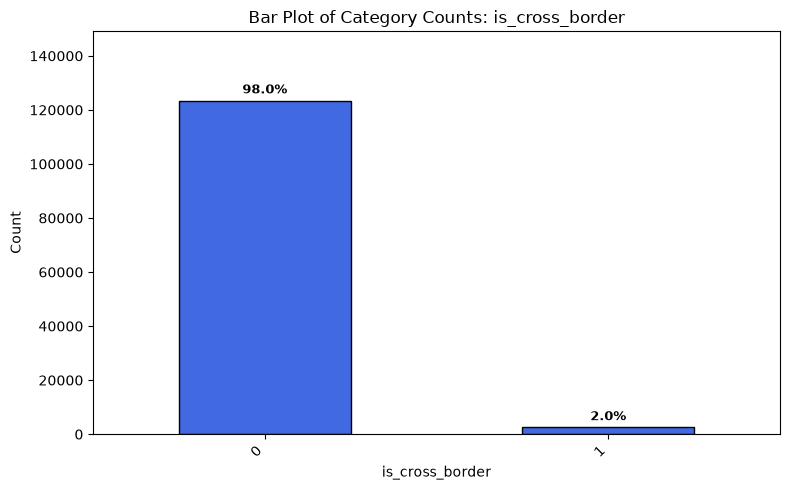

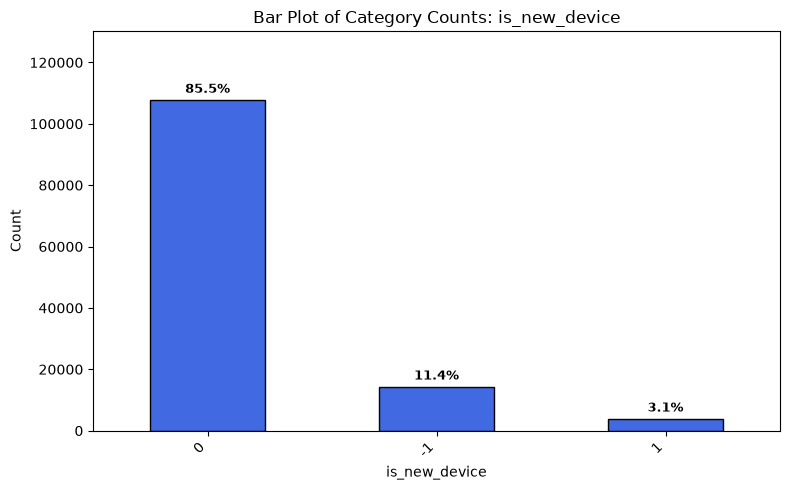

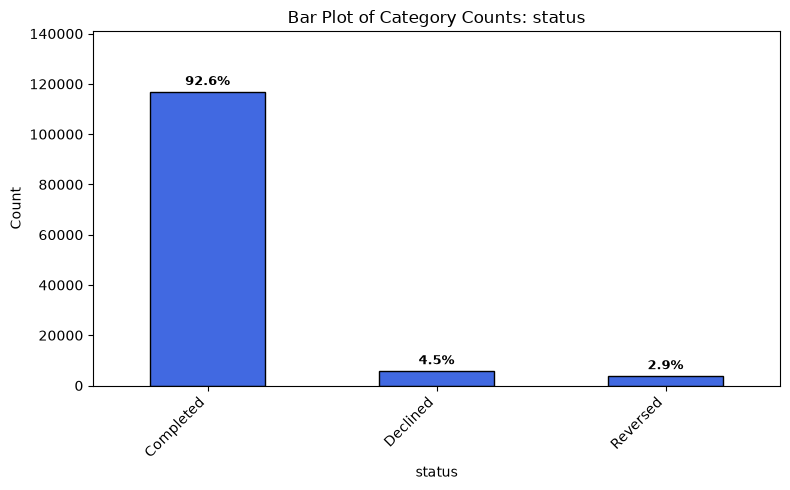

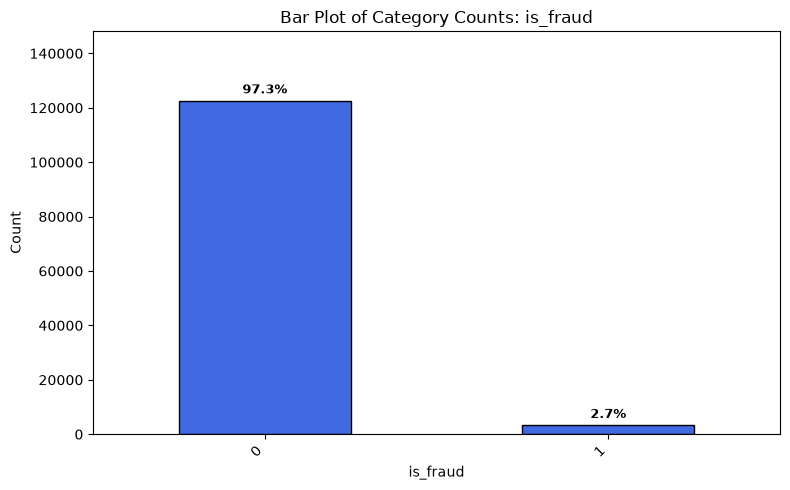

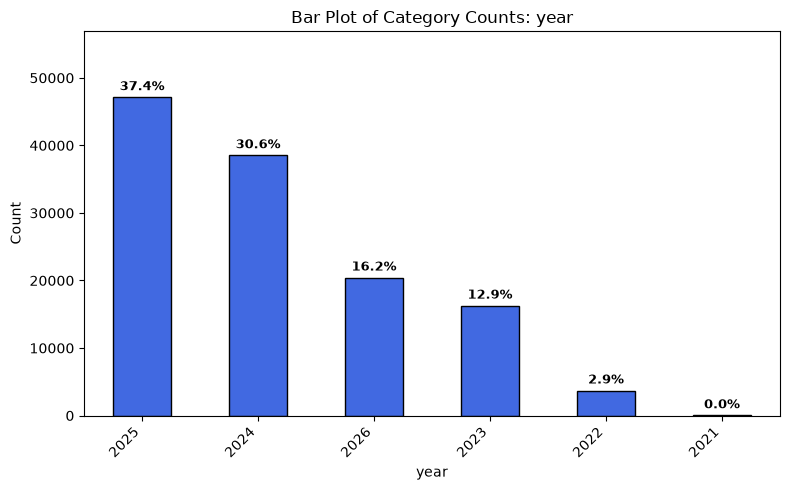

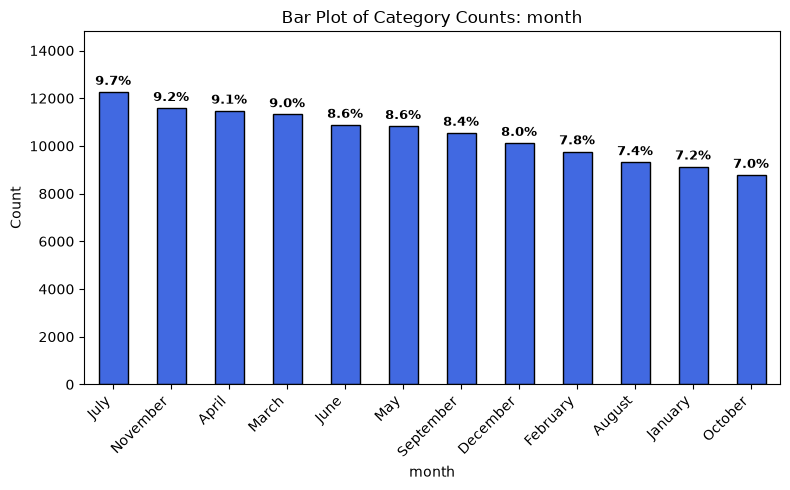

In [11]:
import matplotlib.pyplot as plt

# List only the categorical columns you want to see
columns_to_plot = ['account_type', 'home_country','currency', 'kyc_tier', 'day_of_week', 'hour_of_day','merchant_category','channel','transaction_country', 'is_cross_border','is_new_device','status','is_fraud','year','month']

# Loop only through your specified list
for column in columns_to_plot:
    # check to make sure the column actually exists in your data
    if column in df.columns:
        fig, ax = plt.subplots(figsize=(8, 5)) # Use subplots to easily reference 'ax'
        
        # Count values and plot
        counts = df[column].value_counts()
        counts.plot(kind='bar', edgecolor='black', color='royalblue', ax=ax)
        
        # Total number of observations for calculating percentages
        total_rows = len(df[column].dropna()) # Excludes missing values for accurate percentages
        
        # Add percentages on top of the bars
        for patch in ax.patches:
            height = patch.get_height()
            percentage = (height / total_rows) * 100
            
            # Annotate text
            ax.annotate(f'{percentage:.1f}%', 
                        xy=(patch.get_x() + patch.get_width() / 2, height), # Position text at the top-centre of the bar
                        xytext=(0, 3), # Offset text slightly upwards by 3 points
                        textcoords="offset points",
                        ha='center', 
                        va='bottom', 
                        fontsize=9,
                        fontweight='bold')
        
        plt.title(f'Bar Plot of Category Counts: {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        
        # Pad the top of the y-axis so the labels don't get clipped off the chart boundary
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15) 
        
        plt.tight_layout()
        plt.show()


Description of the data

After cleaning, the number of customers was 1000 with 7144 accounts and 126000 transactions. about 51% of the account type was made of individual accounts. Half of the total number of transactions were made in Nigeria (Home country). Transactions were done 24 hours a day with a peak period between 7am and 9pm. It was also observed that payroll dominated the merchant category (13%) and the most used channel was the mobile app (33%). about 3% of the transactions were from new devices while 11% of the transactions were from unknown devices. Also, 2% of the total number of transactions were cross border. 4.5% of the total transactions were declined, 2.9% reversed and 2.7% were fraudulent. 

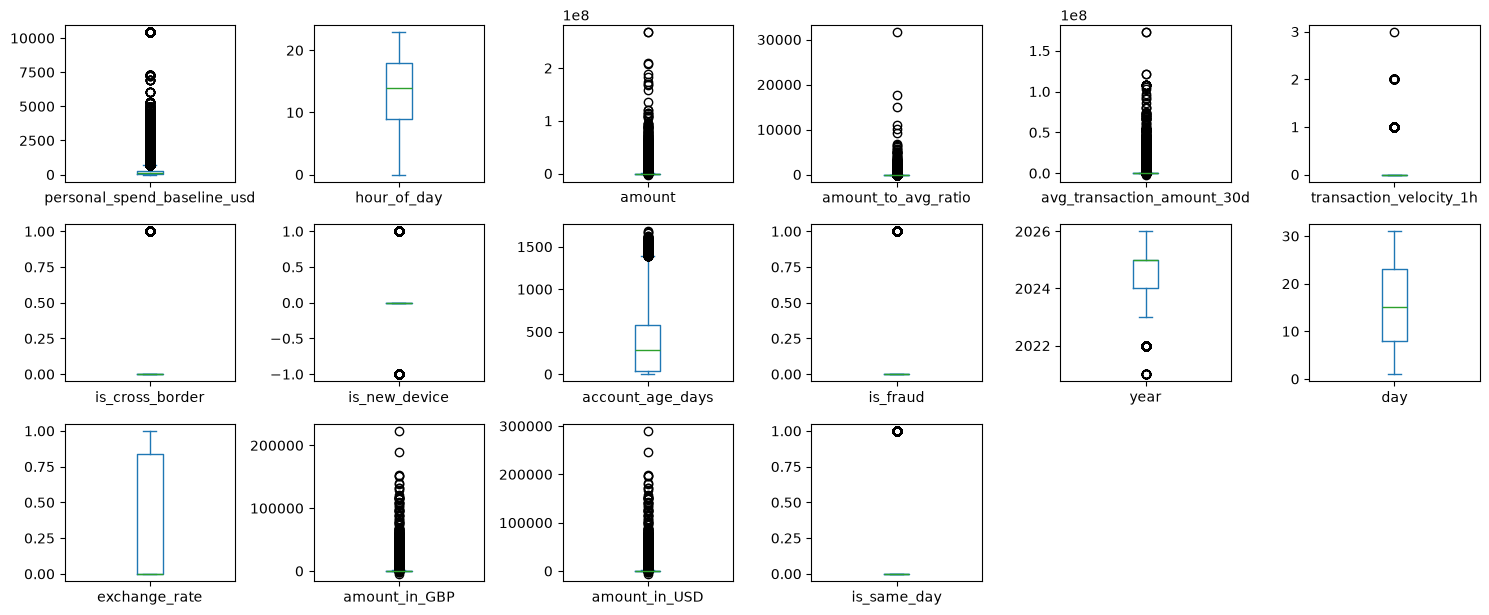

In [ ]:
# visualise numeric data

# Automatically grab only columns containing numbers
numeric_cols = df.select_dtypes(include=['number']).columns

# Adjust figsize based on how many columns you have (Width, Height)
df[numeric_cols].plot(kind='box', subplots=True, layout=(6, 6), figsize=(15, 12), sharex=False, sharey=False)

plt.tight_layout() # Prevents column names from overlapping
plt.show()


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   account_id                   126000 non-null  str    
 1   account_holder_name          126000 non-null  str    
 2   account_type                 126000 non-null  str    
 3   home_country                 126000 non-null  str    
 4   currency                     126000 non-null  str    
 5   kyc_tier                     126000 non-null  str    
 6   account_created_date         126000 non-null  str    
 7   personal_spend_baseline_usd  126000 non-null  float64
 8   transaction_id               126000 non-null  str    
 9   timestamp                    126000 non-null  str    
 10  day_of_week                  126000 non-null  str    
 11  hour_of_day                  126000 non-null  int64  
 12  description                  126000 non-null  str    
 13  merchant_n

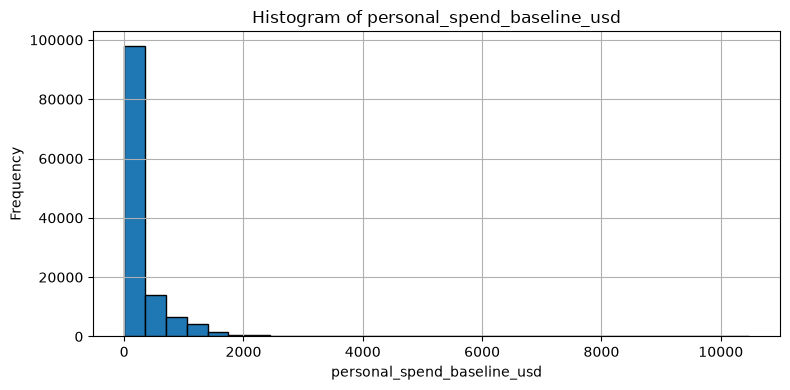

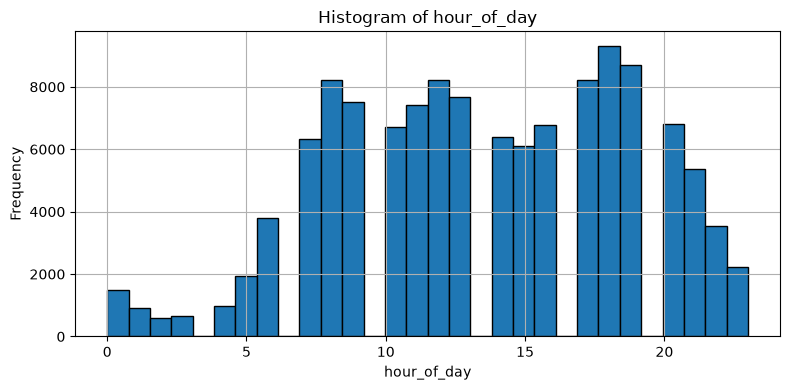

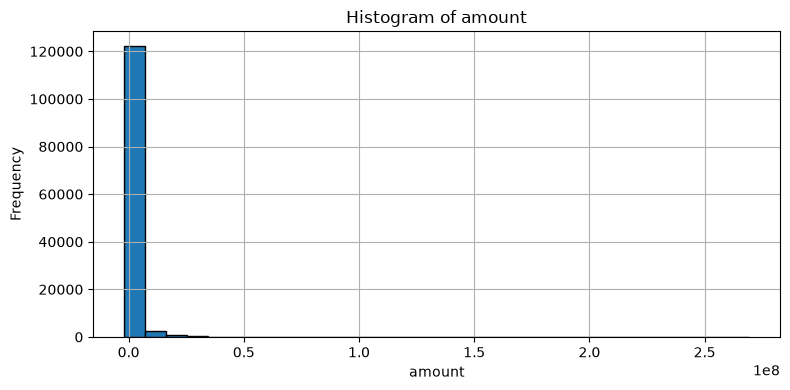

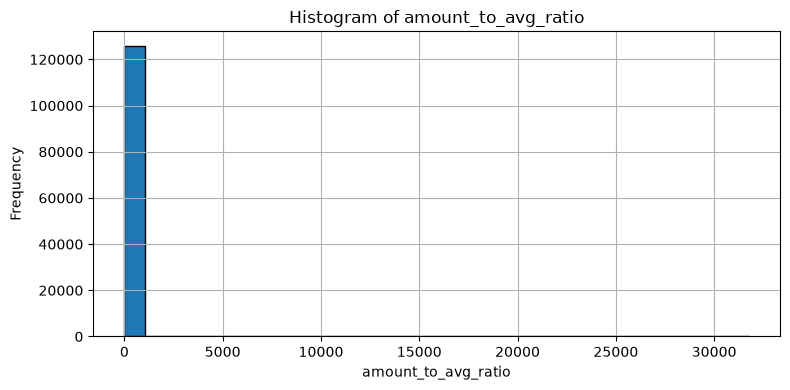

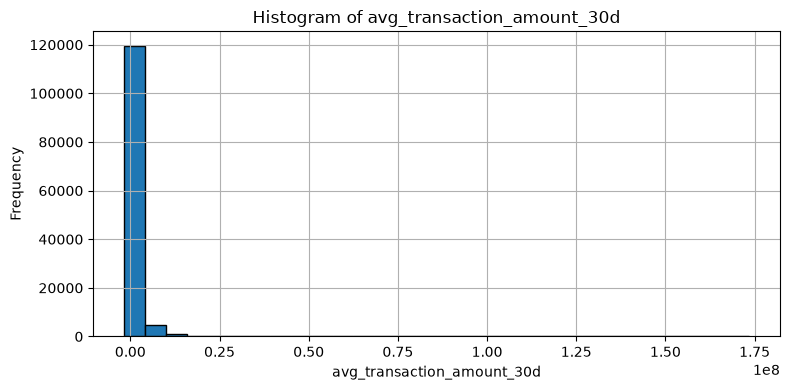

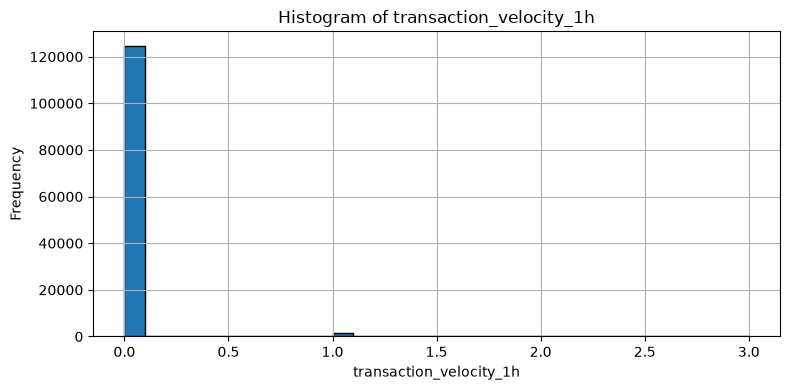

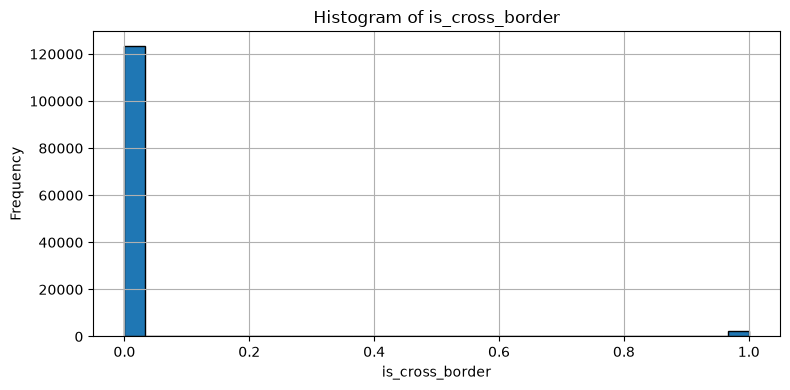

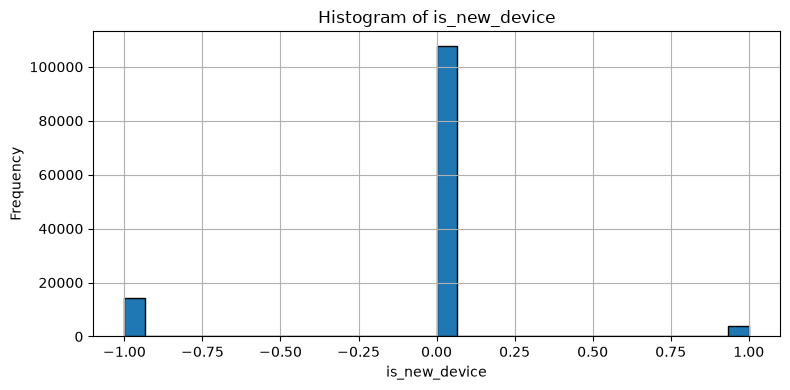

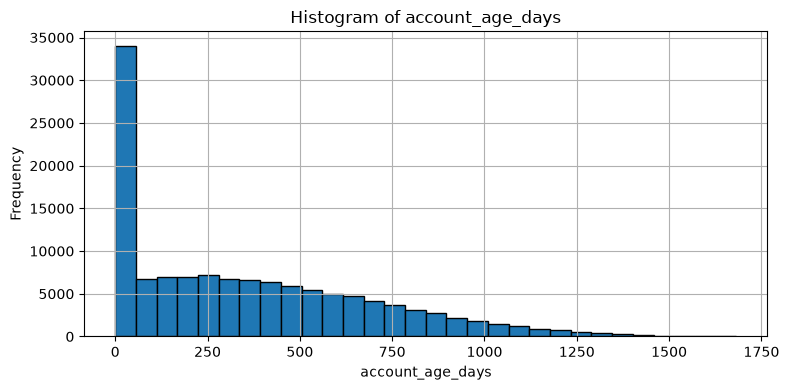

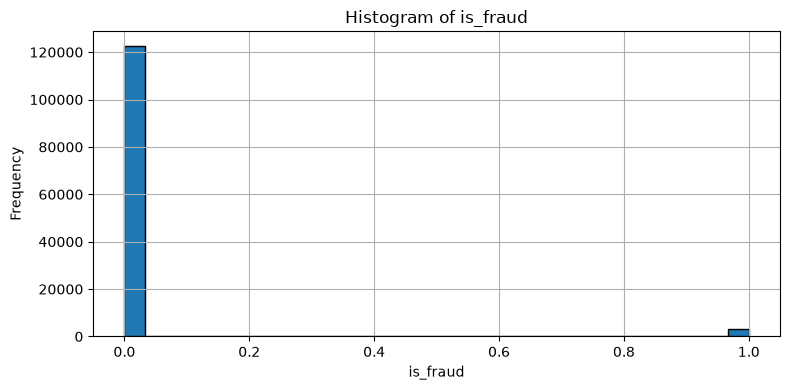

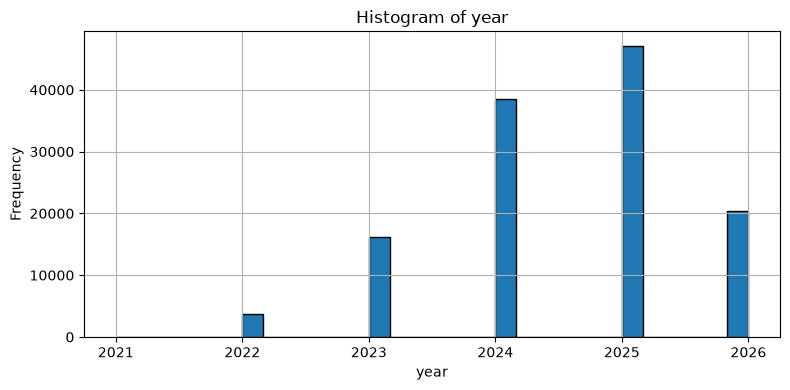

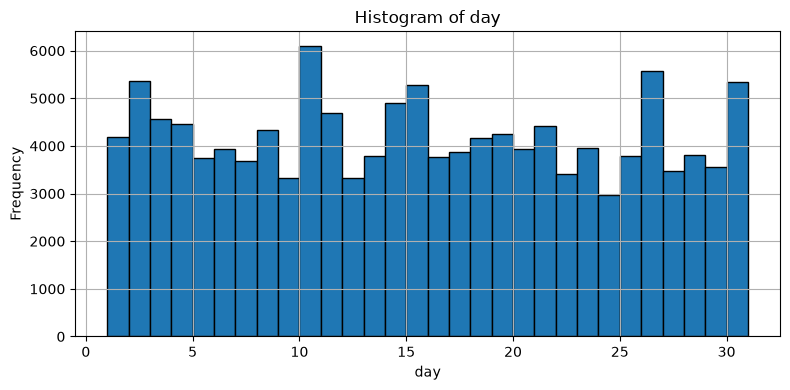

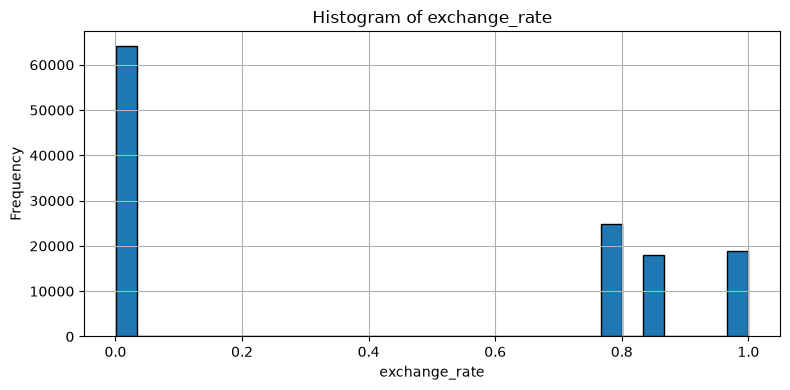

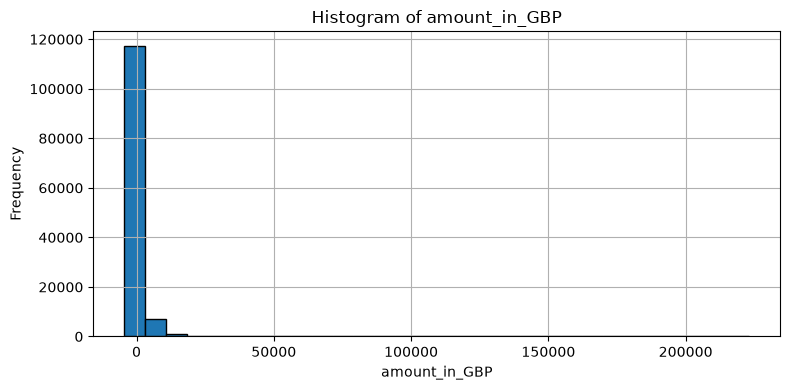

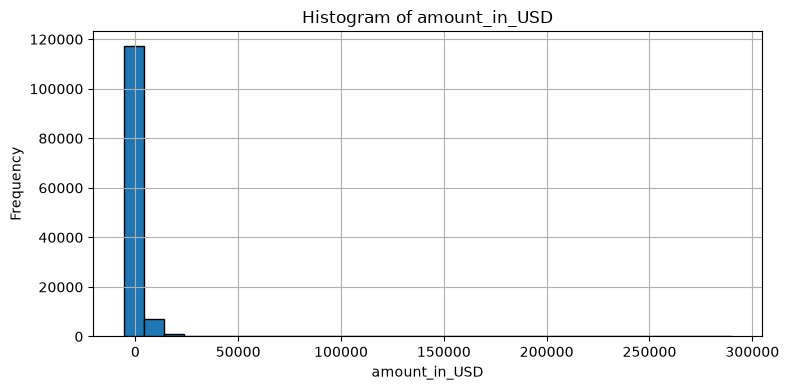

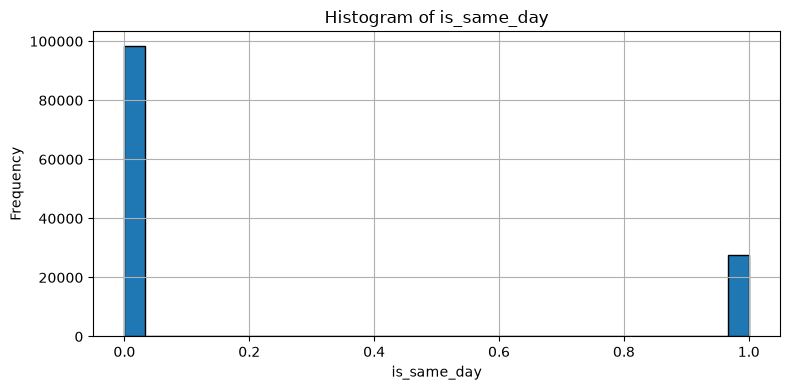

In [ ]:
# histograms

# Loop through each column in the dataframe
for column in df.columns:
    # Check if the column is numerical (skip text/categorical data if desired)
    if df[column].dtype in ['int64', 'float64']:
        plt.figure(figsize=(8, 4))
        
        # Plot individual histogram
        df[column].hist(bins=30, edgecolor='black')
        
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()  # Forces VS Code to render this specific plot before moving to the next


In [15]:
# plots are heavily skewed to the right


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   account_id                   126000 non-null  str    
 1   account_holder_name          126000 non-null  str    
 2   account_type                 126000 non-null  str    
 3   home_country                 126000 non-null  str    
 4   currency                     126000 non-null  str    
 5   kyc_tier                     126000 non-null  str    
 6   account_created_date         126000 non-null  str    
 7   personal_spend_baseline_usd  126000 non-null  float64
 8   transaction_id               126000 non-null  str    
 9   timestamp                    126000 non-null  str    
 10  day_of_week                  126000 non-null  str    
 11  hour_of_day                  126000 non-null  int64  
 12  description                  126000 non-null  str    
 13  merchant_n

Bivariate analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


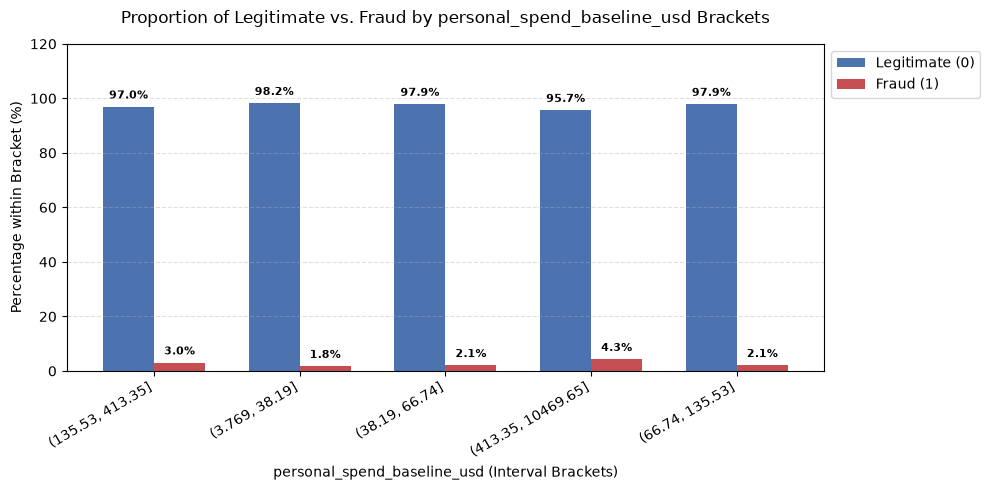

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


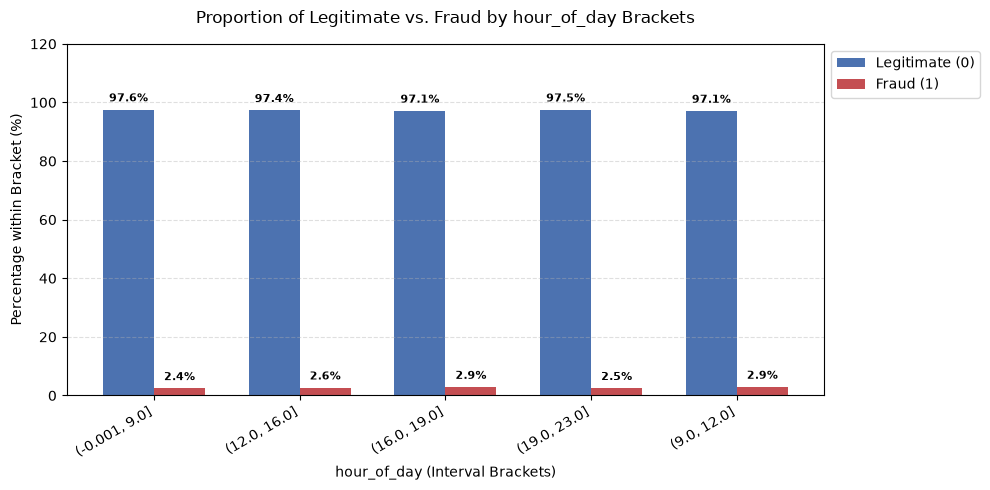

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


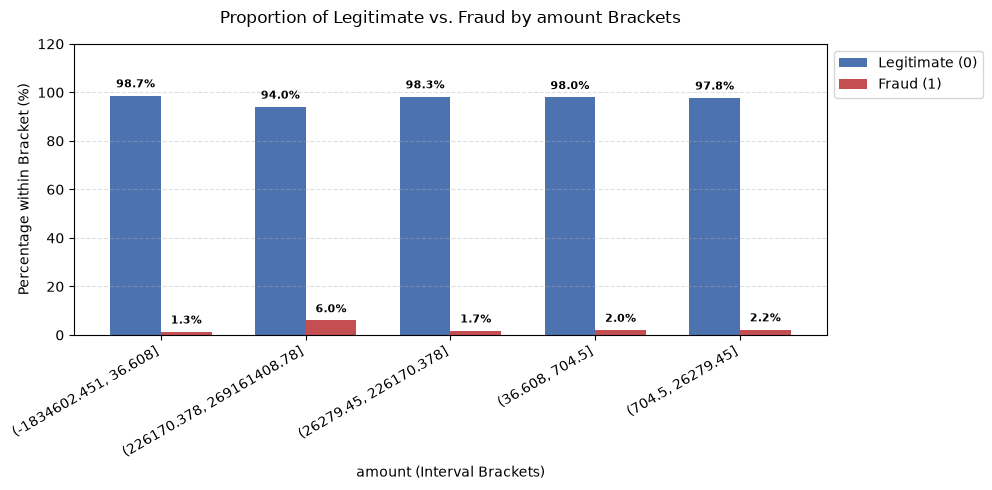

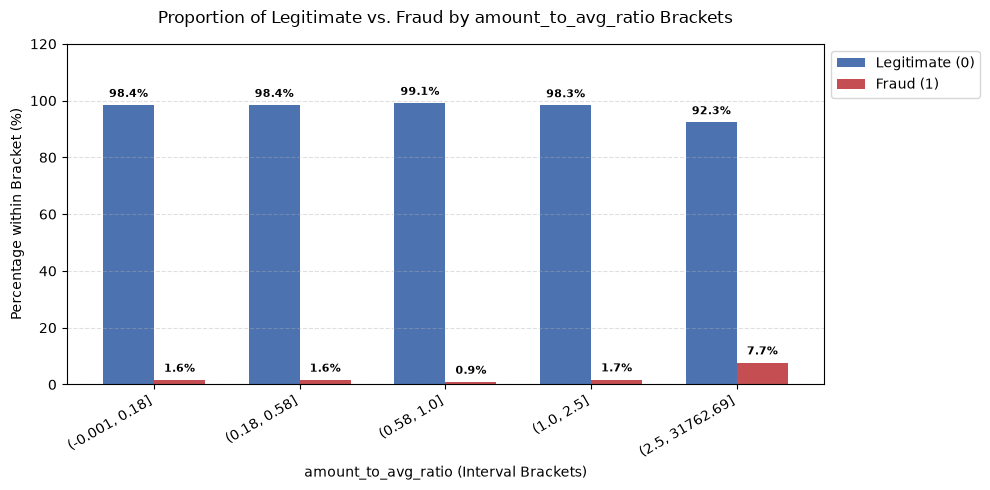

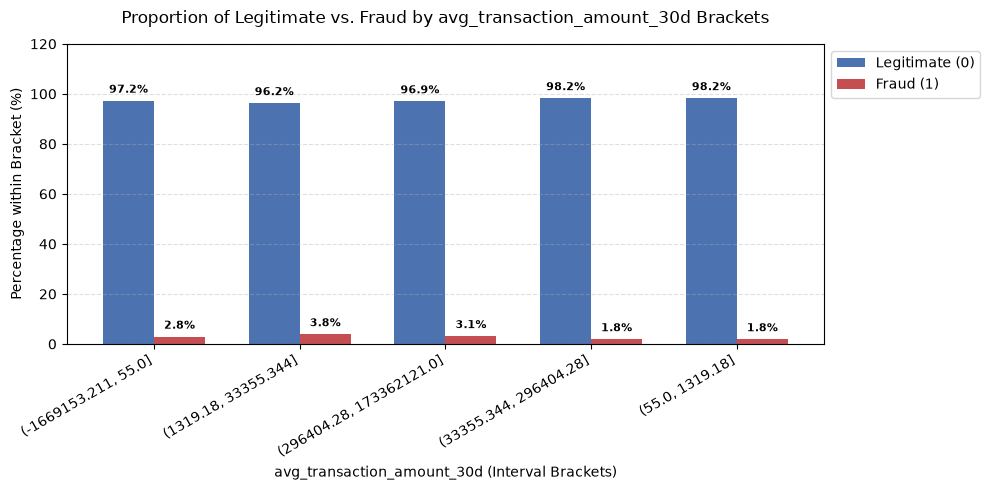

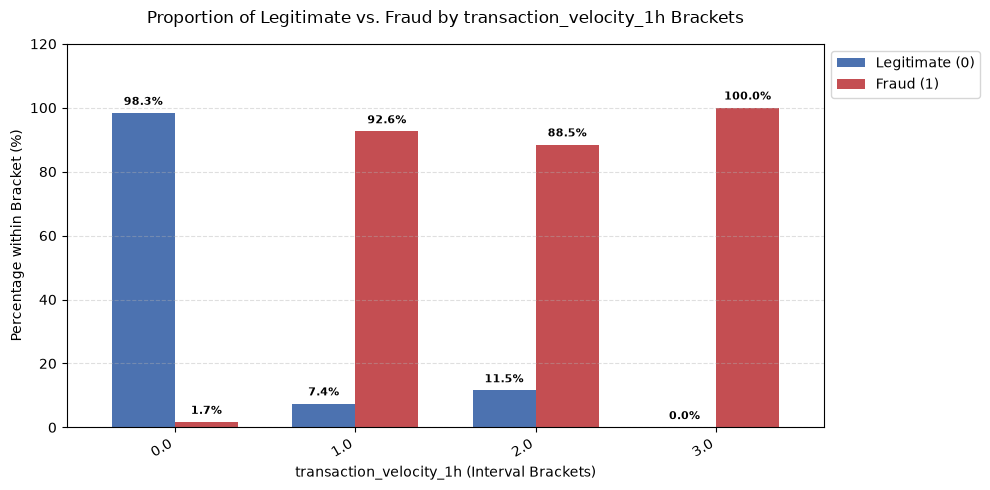

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


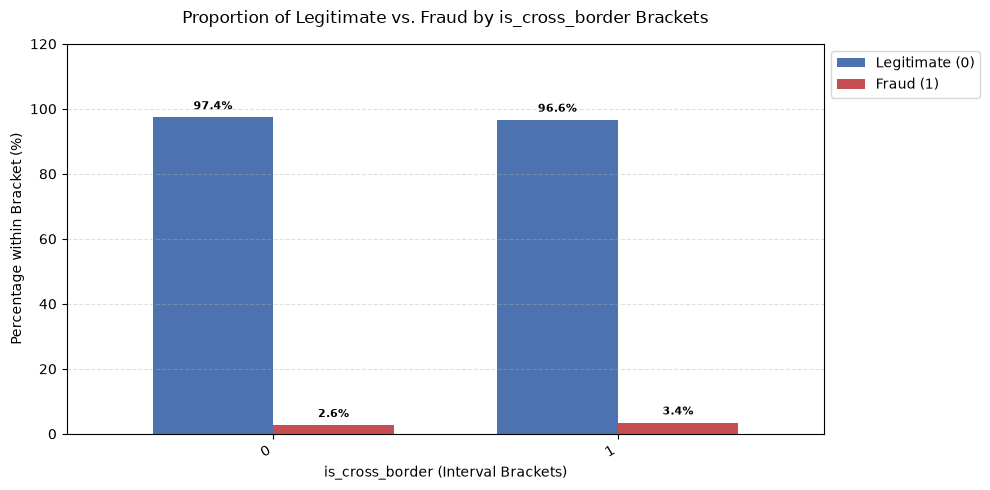

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


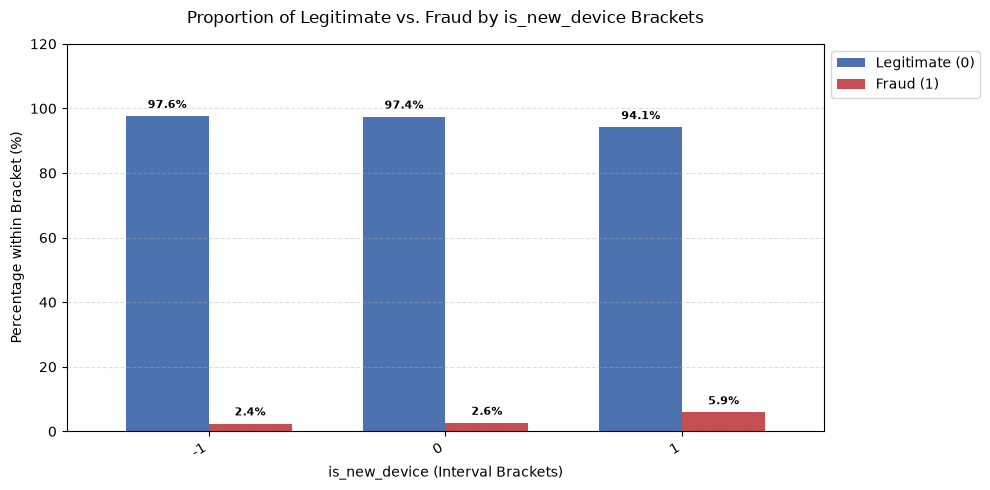

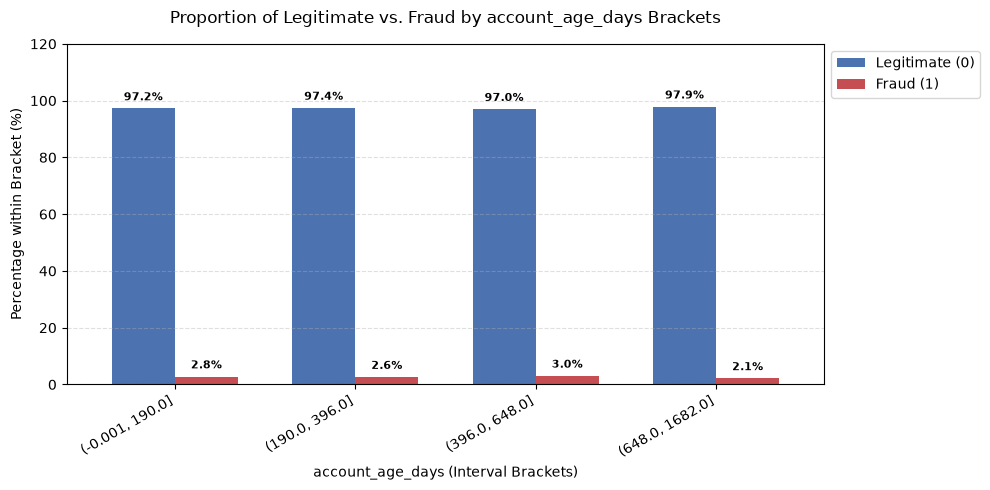

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


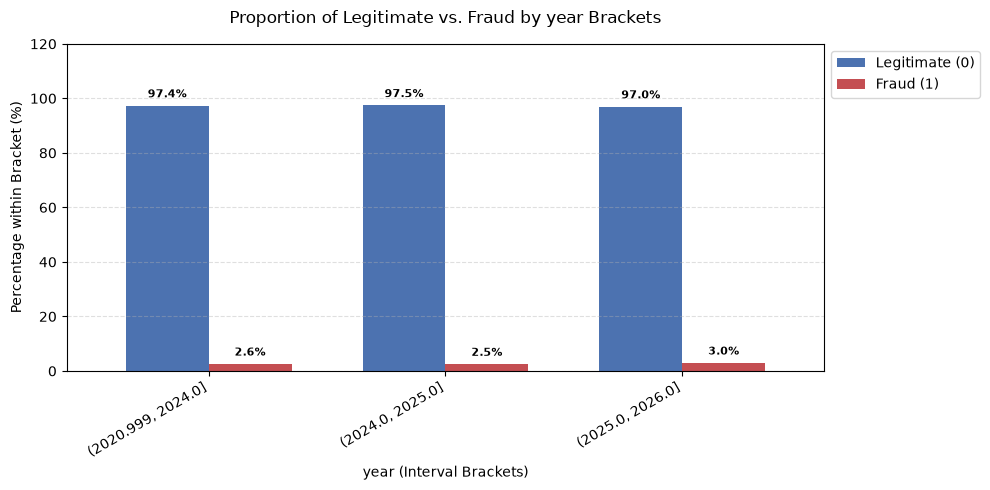

C:\Users\hp\AppData\Local\Temp\ipykernel_17736\1697937050.py:48: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):


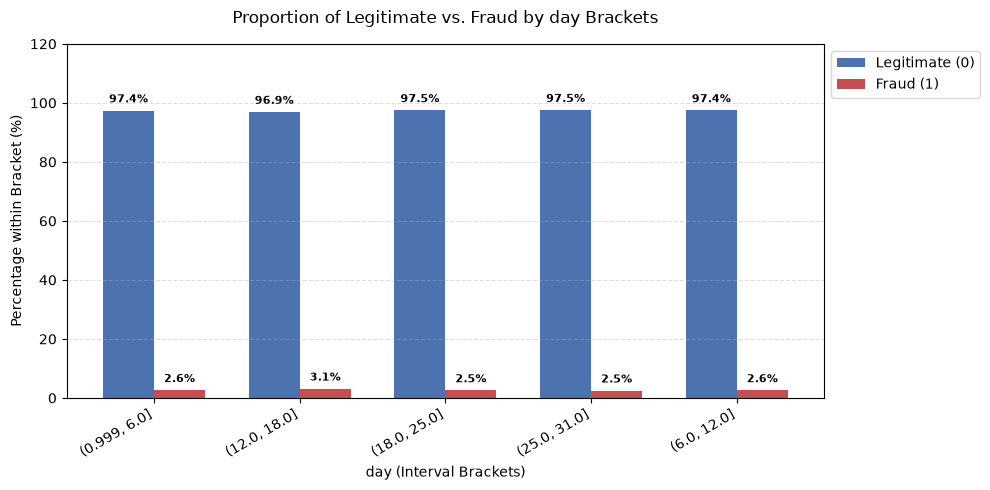

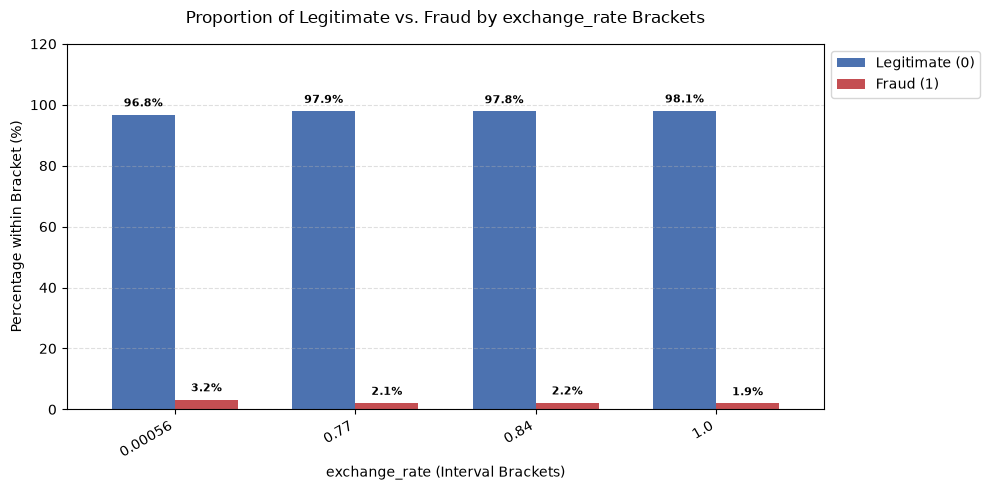

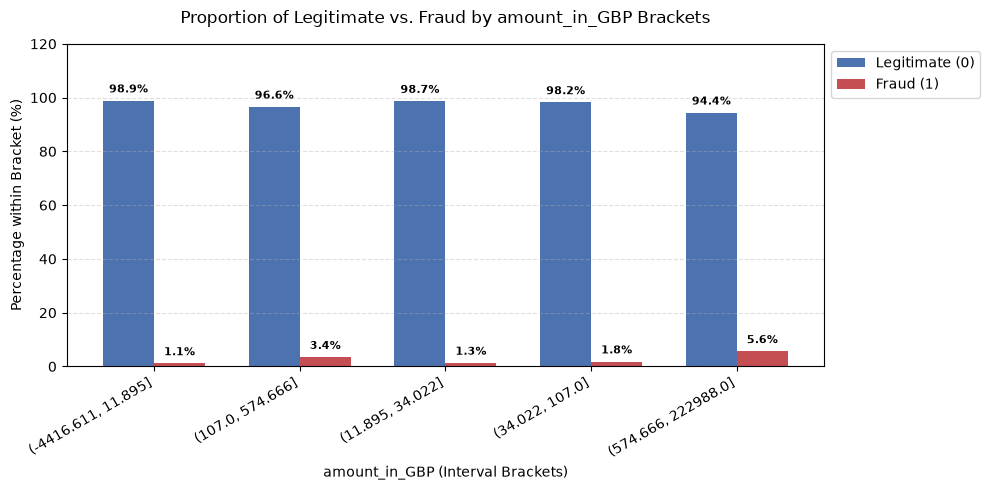

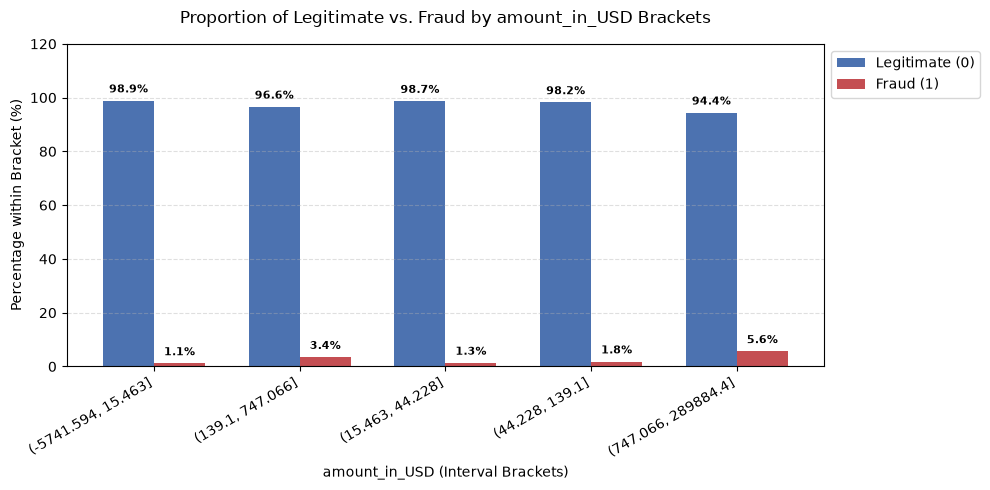

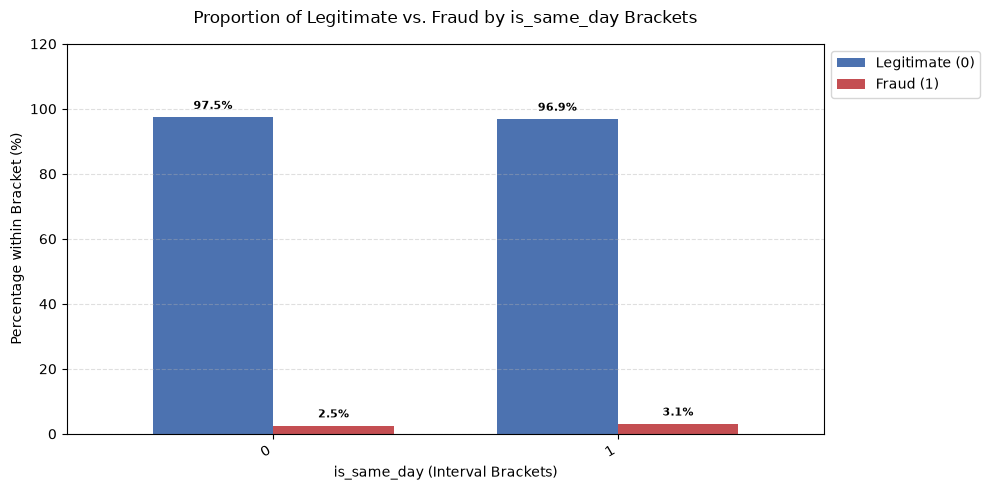

In [17]:

# Target variable designation
target = 'is_fraud'

# Filter out the target column from the loop
features = [col for col in df.columns if col != target]

for col in features:
    
    # 1. Bivariate Analysis for NUMERICAL columns
    if pd.api.types.is_numeric_dtype(df[col]):
        temp_df = df[[col, target]].dropna()
        
        # Determine bins for numerical data
        if temp_df[col].nunique() <= 5:
            temp_df['binned_col'] = temp_df[col].astype(str)
        else:
            try:
                temp_df['binned_col'] = pd.qcut(temp_df[col], q=5, duplicates='drop').astype(str)
            except Exception:
                temp_df['binned_col'] = pd.cut(temp_df[col], bins=5).astype(str)

        # Calculate cross-tab percentages (normalized per bracket row)
        ct = pd.crosstab(temp_df['binned_col'], temp_df[target], normalize='index') * 100
        ct = ct.sort_index()

        # Plot GROUPED bar chart (stacked=False)
        plt.figure(figsize=(10, 5))
        # We grab the 'ax' object to add our floating labels
        ax = ct.plot(kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], width=0.7, ax=plt.gca())
        
        # --- FLOATING LABELS: Places text cleanly above both blue and red bars ---
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=4, weight='bold', fontsize=8)

        plt.title(f'Proportion of Legitimate vs. Fraud by {col} Brackets', fontsize=12, pad=15)
        plt.ylabel('Percentage within Bracket (%)')
        plt.xlabel(f'{col} (Interval Brackets)')
        plt.xticks(rotation=30, ha='right')
        plt.legend(['Legitimate (0)', 'Fraud (1)'], loc='upper left', bbox_to_anchor=(1, 1))
        
        # Give 20% extra vertical headroom so labels don't hit the top of the chart canvas
        plt.ylim(0, 120) 
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

    # 2. Bivariate Analysis for CATEGORICAL columns
    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        if df[col].nunique() > 20:
            print(f"Skipping visualization for '{col}' because it has too many unique values ({df[col].nunique()}).")
            continue
            
        # Calculate cross-tab percentages
        ct = pd.crosstab(df[col], df[target], normalize='index') * 100
        ct = ct.sort_values(by=1, ascending=False) # Sort by highest fraud risk category

        plt.figure(figsize=(10, 5))
        ax = ct.plot(kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], width=0.7, ax=plt.gca())
        
        # --- FLOATING LABELS: Places text cleanly above both blue and red bars ---
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=4, weight='bold', fontsize=8)

        plt.title(f'Proportion of Legitimate vs. Fraud across {col}', fontsize=12, pad=15)
        plt.ylabel('Percentage within Category (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.legend(['Legitimate (0)', 'Fraud (1)'], loc='upper left', bbox_to_anchor=(1, 1))
        
        plt.ylim(0, 120)
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()


The most important indicator of fraudulent transactions was the transaction velocity per hour. At 1.0, 2.0 and 3.0, the percentage of fraud were 92.6%, 88.5% and 100% respectively. Transactions with an amount-to-average ratio of 2.5 showed a 7.7% fraud rate. transactions from new devices exhibited a 5.9% fraud rate. For transaction amounts above 747,000, 5.6% of the transactions were fraudulent. from same day accounts, 3.1% of the transactions were fraudulent.

Correlation matrix

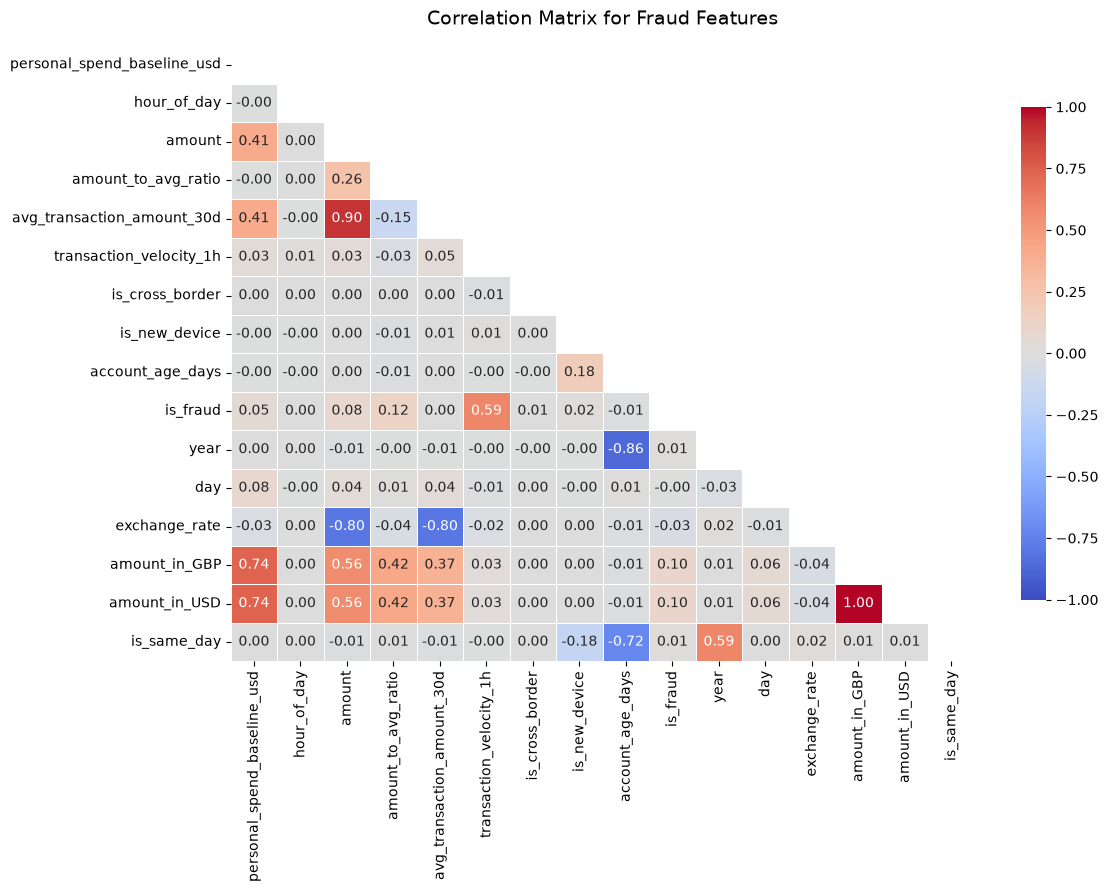

In [23]:

# 1. Select only numerical columns (and your binary target, e.g., 'is_fraud')
numerical_df = df.select_dtypes(include=['number'])

# 2. Compute the Pearson correlation matrix
corr_matrix = numerical_df.corr(method='spearman')

# 3. Generate a mask for the upper triangle (optional, reduces visual clutter)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Hides the redundant upper triangle
    cmap='coolwarm',         # Red is positive, blue is negative correlation
    vmax=1.0, vmin=-1.0,     # Standard correlation bounds
    center=0,                # 0 (no correlation) is white/neutral
    annot=True,              # Display correlation coefficient values
    fmt=".2f",               # Round numbers to 2 decimal places
    linewidths=0.5,          # Space between squares
    cbar_kws={"shrink": .8}  # Scale down the color bar
)

plt.title('Correlation Matrix for Fraud Features', fontsize=14, pad=15)
plt.show()


Below are the key drivers of fraud:

- transaction_velocity_1h has the strongest correlation with fraud (0.59). This means as the number of transactions attempted within a single hour spikes, the probability of it being a fraud attack increases dramatically.
- amount_to_avg_ratio has a positive correlation of 0.12. as the transaction amount deviates further upward from the user's historical baseline, the likelihood of fraud increases.
- is_new_device shows a near-zero linear correlation (0.02) to fraud on its own. while it is a crucial risk indicator, it behaves as a non-linear or combinatorial feature. A new device by itself isn't necessarily fraud (e.g., people upgrade phones), but it becomes critical when combined with a high velocity or a massive amount-to-average ratio.
- personal spend baseline has a positive correlation of 0.05. this implies that as it increases the probability of the transaction being a fraud also increases. 